# Le 91,9 % survit-il hors des conditions apprises ?

**Oui, en conditions de fonctionnement.** Au pire 0,889 sur une région entière
jamais vue. C'est le résultat principal. Depuis le début du projet, chaque
expérience a fait baisser un chiffre. Celle-ci, fuites fermées, montre que le
modèle **généralise** d'une région du domaine à une autre.

L'extrapolation en **sévérité** est une autre question, mesurée à part, sur
quatre classes seulement. Les deux ventilateurs en sont exclus : le générateur
ne produit pas de version légère. Une première coupe qui les laissait dedans
a publié 0,426 et 0,288 — **ces chiffres sont retirés**, ils mesuraient une
classe absente du train.

> Grille : `EDA/x4_compute.py`. Ce notebook recharge la table et refait le contrôle.


In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, display
from sklearn.model_selection import train_test_split

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'requirements.txt').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'EDA'))

from x4_compute import FEATURE_COLUMNS, LABELS, SEV_LABELS, FAN_LABELS, SEED, FIG, TABLE, fit_rf
from tools.results import value, get

df = pd.read_csv(ROOT / 'outputs' / 'synthetic' / 'dataset.csv')
print(f'{len(df)} lignes · {df.fault_type.nunique()} classes')
print('sévérité par classe')
for lab, g in df.groupby('fault_type'):
    if lab == 'Normal':
        print(f'  {lab:24s} n={len(g)}')
        continue
    s = g.fault_severity
    print(f'  {lab:24s} min={s.min():.2f}  max={s.max():.2f}  n<0.20={(s<0.20).sum():4d}  n>=0.20={(s>=0.20).sum():4d}')


5000 lignes · 6 classes
sévérité par classe
  Condenser_Fan_Fault      min=0.20  max=0.60  n<0.20=   0  n>=0.20= 500
  Condenser_Fouling        min=0.15  max=0.50  n<0.20= 120  n>=0.20= 630
  Evaporator_Fan_Fault     min=0.20  max=0.60  n<0.20=   0  n>=0.20= 500
  Evaporator_Fouling       min=0.15  max=0.50  n<0.20=  98  n>=0.20= 652
  Normal                   n=2000
  Refrigerant_Undercharge  min=0.10  max=0.35  n<0.20= 193  n>=0.20= 307


### Protocole

Même `Pipeline` (scaler + Random Forest livré) que le 91,9 %. La région tenue
à l'écart n'entre ni dans le scaler, ni dans l'entraînement, ni dans la val.
Wilson 95 %. Deux scores dont les intervalles se chevauchent sont ex æquo.


In [2]:
y = df['fault_type']
X = df[FEATURE_COLUMNS]
X_tv, X_te, y_tv, y_te = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y)
X_tr, X_va, y_tr, y_va = train_test_split(X_tv, y_tv, test_size=0.25, random_state=SEED, stratify=y_tv)
packed = fit_rf(X_tr, y_tr, X_va, y_va, X_te, y_te)
print(f"contrôle {len(X_tr)}/{len(X_va)}/{len(X_te)}")
print(f"acc={packed['acc']:.4f} [{packed['lo']:.3f}, {packed['hi']:.3f}]  F1={packed['f1']:.3f}")
x0 = value(experiment='X0', protocol='holdout-test', reference='simulated',
           features='24-col', model='random-forest', metric='accuracy')
print('X0 publié', x0)
assert abs(packed['acc'] - x0) < 0.025
print('contrôle OK')


contrôle 2625/875/1500
acc=0.9187 [0.904, 0.931]  F1=0.918
X0 publié 0.918667
contrôle OK


## 1 — Conditions de fonctionnement : le 91,9 % survit

C'est le résultat à retenir. Quatre découpages, tous dans l'intervalle Wilson
du contrôle — ou à sa lisière.


aléatoire (référence)             0.919 [0.904, 0.931]  F1=0.918  n=1500
T_setpoint > 48 °C                0.889 [0.871, 0.904]  F1=0.882  n=1366
T_ambient < −5 °C                 0.893 [0.870, 0.913]  F1=0.883  n=804
speed_ratio > 0.85                0.920 [0.902, 0.935]  F1=0.916  n=1077
GroupKFold (T_amb × T_set)        0.911 [0.903, 0.919]  F1=0.911  n=5000


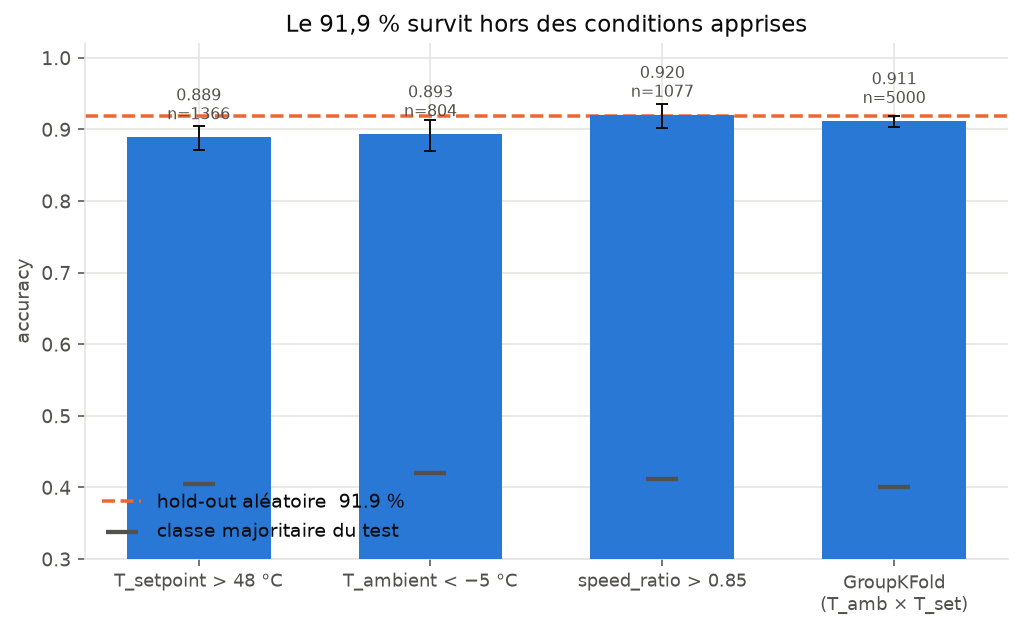

In [3]:
tab = pd.read_csv(TABLE)
op = [
    'holdout-random-control',
    'holdout-domain-speed>0.85',
    'holdout-domain-GroupKFold',
    'holdout-domain-Tamb<-5',
    'holdout-domain-Tsink>48',
]
sub = tab[tab.protocol.isin(op)].copy()
for r in sub.itertuples():
    print(f'{r.split:32s}  {r.acc:.3f} [{r.acc_lo:.3f}, {r.acc_hi:.3f}]  F1={r.f1:.3f}  n={r.n_test}')
display(Image(str(FIG)))


`T_ambient`, `T_setpoint`, `speed` sont aux derniers rangs d'importance.
`d_COP` est 9ᵉ (0,034) — le niveau P0, plus une fuite. Les signatures
physiques se transfèrent.

## 2 — Sévérité, quatre classes seulement

Les ventilateurs n'ont **aucun** exemple sous 0,20. Les laisser dans le
découpage faisait F1 = 0,000 sur une classe jamais vue. Univers retenu :
`Normal`, `Condenser_Fouling`, `Evaporator_Fouling`, `Refrigerant_Undercharge`.
`Normal` reste au train. Test = les défauts de la bande de sévérité.


In [4]:
print('exclus', FAN_LABELS)
print('univers', SEV_LABELS)
sev = tab[tab.protocol.str.contains('4class')].copy()
for r in sev.itertuples():
    mix = {k: int(getattr(r, f'n_{k}')) for k in SEV_LABELS if getattr(r, f'n_{k}')}
    print(f'\n{r.split}')
    print(f'  acc={r.acc:.3f} [{r.acc_lo:.3f}, {r.acc_hi:.3f}]  F1={r.f1:.3f}  n={r.n_test}  maj={r.majority:.3f}')
    print('  test mix', mix)
    print('  par classe', {k: f"{getattr(r, 'f1_' + k):.3f}" for k in SEV_LABELS if getattr(r, 'n_' + k)})


exclus ['Condenser_Fan_Fault', 'Evaporator_Fan_Fault']
univers ['Normal', 'Condenser_Fouling', 'Evaporator_Fouling', 'Refrigerant_Undercharge']

sévérité < 0.20 (4 classes)
  acc=0.428 [0.381, 0.477]  F1=0.496  n=411  maj=0.470
  test mix {'Condenser_Fouling': 120, 'Evaporator_Fouling': 98, 'Refrigerant_Undercharge': 193}
  par classe {'Condenser_Fouling': '0.603', 'Evaporator_Fouling': '0.424', 'Refrigerant_Undercharge': '0.462'}

sévérité ≥ 0.20 (4 classes)
  acc=0.469 [0.445, 0.494]  F1=0.540  n=1589  maj=0.410
  test mix {'Condenser_Fouling': 630, 'Evaporator_Fouling': 652, 'Refrigerant_Undercharge': 307}
  par classe {'Condenser_Fouling': '0.590', 'Evaporator_Fouling': '0.418', 'Refrigerant_Undercharge': '0.613'}


Naissant **0,428 [0,381 – 0,477]**, sous la classe majoritaire (0,470).
Inverse **0,469 [0,445 – 0,494]**. Sous-charge sévère : 307 / 307 corrects
— entraîner sur du naissant aide quand le défaut s'aggrave, pour cette
classe. L'encrassement évaporateur ne transfère pas (F1 0,42).

## 3 — Détection binaire, six classes

Fault contre Normal. Les classes s'effondrent en deux, les ventilateurs
restent. 30 % des `Normal` sont tenus à l'écart avec le test, sinon
l'accuracy n'a pas de faux positifs au dénominateur.


In [5]:
for proto, label in [
    ('holdout-binary-severity-train<0.20', 'train mild → test severe'),
    ('holdout-binary-severity-train>=0.20', 'train severe → test mild'),
]:
    acc = get(experiment='X4', protocol=proto, label='__global__', metric='accuracy')[0]
    rec = get(experiment='X4', protocol=proto, label='Fault', metric='recall')[0]
    print(f'{label:32s}  acc={float(acc["value"]):.3f}  n={acc["n"]}  '
          f'recall Fault={float(rec["value"]):.3f}  {rec["note"]}')


train mild → test severe          acc=0.762  n=3189  recall Fault=0.710  FPR=0.013; TP=1837 FN=752 FP=8 TN=592
train severe → test mild          acc=0.887  n=1011  recall Fault=0.805  FPR=0.057; TP=331 FN=80 FP=34 TN=566


Entraîné sur du marqué, testé sur du naissant : **0,887**, rappel 0,805,
FPR 0,057 — on voit venir 80 % des pannes comme « un problème ». L'autre
sens est conservateur (FPR 0,013) et rate 29 % des défauts marqués.

## Verdict

1. Le 91,9 % **survit** à l'extrapolation en conditions de fonctionnement — au pire 0,889.
2. L'extrapolation en **sévérité** est mesurée sur quatre classes seulement : 0,428 naissant, 0,469 inverse.
3. Les deux défauts de ventilateur en sont exclus parce que **le générateur ne produit pas de version légère**, limite du simulateur à corriger plus tard.

Nombres : `outputs/results.csv` (`experiment=X4`). Les protocoles
`holdout-domain-severity<0.20` et `>=0.20` ont été retirés.
